In [32]:
import polars as pl
import matplotlib.pyplot as plt

from spells import summon, ColSpec, ColType, ColName
from deq.plot import line_plot


In [90]:

set_code = "TDM"
filter_spec = {
    '$and': [
        {'player_cohort': 'Top'},
        {'pack_num': 1},
        {'op': '<', 'lhs': 'pick_num', 'rhs': 14},
        {'op': '>', 'lhs': 'format_day', 'rhs': 12}
    ]
}

ext = {
    'pick_rate_logit': ColSpec(
        col_type=ColType.AGG,
        expr=pl.when(pl.col(ColName.NUM_TAKEN)>0).then(
            (pl.col(ColName.NUM_TAKEN) / (pl.col(ColName.NUM_SEEN) - pl.col(ColName.NUM_TAKEN))).log() - pl.lit(1.0/14.0).log()
        ).otherwise(None)
    ),
}

df = summon(
    'TDM',
    ['pick_rate_logit'],
    group_by=['name', 'pick_num'],
    filter_spec = filter_spec,
    extensions=ext
)

means_df = summon(
    "TDM",
    ["ata", "pick_rate_logit", "rarity"],
    filter_spec=filter_spec,
    extensions=ext
)

In [95]:

cards = [
    "Caustic Exhale",
    "Salt Road Packbeast",
    "Dispelling Exhale"
    
]



# card_df = df.filter(~pl.col('pick_rate_logit').is_null()).filter(pl.col('name').is_in(cards)).filter(pl.col('pick_num') < 10)
card_df = df.filter(pl.col('rarity') == "common").filter(pl.col('ata') > 3).filter(pl.col('ata') < 7)
card_means = means_df.filter(pl.col('rarity') == "common").filter(pl.col('ata') > 3).filter(pl.col('ata') < 7)
# card_means = means_df.filter(pl.col('name').is_in(cards))

ColumnNotFoundError: unable to find column "rarity"; valid columns: ["name", "pick_num", "pick_rate_logit"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'filter' <---
DF ["name", "pick_num", "pick_rate_logit"]; PROJECT */3 COLUMNS

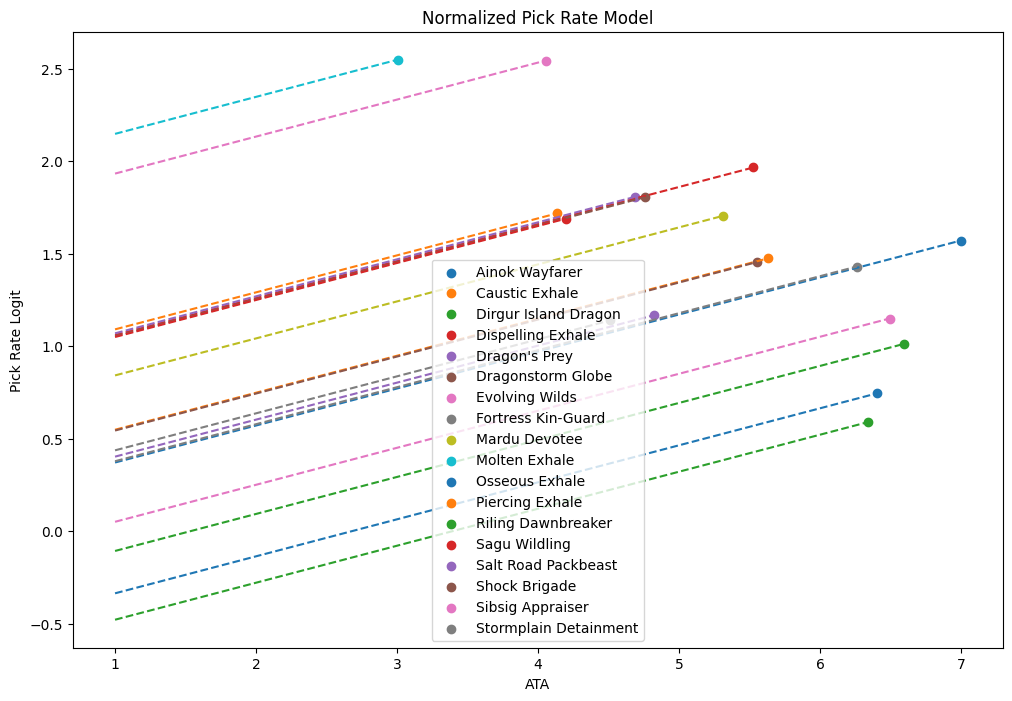

In [94]:
# ax = line_plot(card_df.sort('pick_num').pivot(on="name", index="pick_num", values="pick_rate_logit"), return_ax=True)
_, ax = plt.subplots(figsize=(12,8))
for row in card_means.to_dicts():
    ax.scatter(row['ata'], row['pick_rate_logit'], label=row['name'])
    ax.plot([1, row['ata']], [row['pick_rate_logit'] - 0.2 * (row['ata']-1), row['pick_rate_logit']], linestyle='--')
ax.set_title('Normalized Pick Rate Model')    
ax.set_ylabel('Pick Rate Logit')
ax.set_xlabel('ATA')
ax.legend()

{'name': 'Abzan Devotee', 'ata': 9.378228782287822, 'pick_rate_logit': -0.6107735207589875}
{'name': 'Abzan Monument', 'ata': 8.121783876500858, 'pick_rate_logit': -0.1643550276940009}
{'name': 'Adorned Crocodile', 'ata': 11.41281512605042, 'pick_rate_logit': -1.0131821120842557}
{'name': 'Aegis Sculptor', 'ata': 7.901069518716578, 'pick_rate_logit': -0.521917433903548}
{'name': 'Agent of Kotis', 'ata': 10.733235077376566, 'pick_rate_logit': -0.5665547962124373}
{'name': 'Aggressive Negotiations', 'ata': 10.334648257725181, 'pick_rate_logit': -0.4903871223244032}
{'name': 'Ainok Wayfarer', 'ata': 6.932150313152401, 'pick_rate_logit': 0.6934454654242004}
{'name': "Alchemist's Assistant", 'ata': 6.463730569948186, 'pick_rate_logit': -0.3023774140538964}
{'name': "Alesha's Legacy", 'ata': 11.53781512605042, 'pick_rate_logit': -1.2951272476157398}
{'name': 'All-Out Assault', 'ata': 1.2994011976047903, 'pick_rate_logit': 3.112660242890641}
